## PCA + LDA Image Classifier ##

### Images Splitter ###
only run once unless there are new images for datasets

In [2]:
#Split the images into train and test datasets

from pathlib import Path
import shutil
import random

# =========================
# CONFIG
# =========================
SOURCE_DIR = Path("./Images/Processed/P")   # your current dataset root
OUTPUT_DIR = Path("./datasets")      # new output folder
TRAIN_COUNT = 10
MIN_TEST_COUNT = 2

# allowed image extensions
IMAGE_EXTS = {".jpg", ".jpeg"}

# set seed for reproducibility
random.seed(42)


def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTS


def safe_folder_name(name: str) -> str:
    # convert spaces to underscores for cleaner filenames
    return name.strip().replace(" ", "_")


def main():
    if not SOURCE_DIR.exists():
        raise FileNotFoundError(f"Source directory not found: {SOURCE_DIR}")

    # create output structure
    train_root = OUTPUT_DIR / "train"
    test_root = OUTPUT_DIR / "test"
    train_root.mkdir(parents=True, exist_ok=True)
    test_root.mkdir(parents=True, exist_ok=True)

    person_dirs = [p for p in SOURCE_DIR.iterdir() if p.is_dir()]

    if not person_dirs:
        print("No person folders found.")
        return

    for person_dir in sorted(person_dirs):
        person_name = safe_folder_name(person_dir.name)

        images = [p for p in person_dir.iterdir() if is_image_file(p)]
        images.sort()

        if len(images) == 0:
            print(f"[SKIP] {person_dir.name}: no images found")
            continue

        random.shuffle(images)
        total = len(images)

        # Decide split
        if total >= TRAIN_COUNT + MIN_TEST_COUNT:
            train_imgs = images[:TRAIN_COUNT]
            test_imgs = images[TRAIN_COUNT:]
        elif total >= MIN_TEST_COUNT + 1:
            # keep at least 2 test if possible, rest train
            test_imgs = images[-MIN_TEST_COUNT:]
            train_imgs = images[:-MIN_TEST_COUNT]
        else:
            # too few images, put all into train
            train_imgs = images
            test_imgs = []

        # create class folders
        train_person_dir = train_root / person_name
        test_person_dir = test_root / person_name
        train_person_dir.mkdir(parents=True, exist_ok=True)
        test_person_dir.mkdir(parents=True, exist_ok=True)

        # copy + rename train images
        for i, img_path in enumerate(train_imgs, start=1):
            new_name = f"{person_name}_{i:03d}{img_path.suffix.lower()}"
            shutil.copy2(img_path, train_person_dir / new_name)

        # copy + rename test images
        for j, img_path in enumerate(test_imgs, start=1):
            new_name = f"{person_name}_test_{j:03d}{img_path.suffix.lower()}"
            shutil.copy2(img_path, test_person_dir / new_name)

        print(
            f"[DONE] {person_dir.name} -> "
            f"train: {len(train_imgs)}, test: {len(test_imgs)}"
        )

    print(f"\nFinished. Output saved to: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

[DONE] P_Fathiah -> train: 6, test: 2
[DONE] P_Fazil -> train: 10, test: 2
[DONE] P_Jasper -> train: 10, test: 6
[DONE] P_Joe -> train: 10, test: 4
[DONE] P_Mikail -> train: 10, test: 2
[DONE] P_Roy -> train: 9, test: 2
[DONE] P_Syarah -> train: 10, test: 5

Finished. Output saved to: /workspaces/IE4228-Assignment/datasets


In [2]:
"""
1. load images

2. assign labels from folder names

3. flatten each image into a vector

4. apply PCA on train

5. apply LDA on PCA output

6. evaluate on test

7. save model
"""

'\n1. load images\n\n2. assign labels from folder names\n\n3. flatten each image into a vector\n\n4. apply PCA on train\n\n5. apply LDA on PCA output\n\n6. evaluate on test\n\n7. save model\n'

In [5]:
import os
import cv2
import numpy as np

IMG_SIZE = (90, 90)   # recommended in assignment


def load_dataset(dataset_path):
    
    X = []
    y = []
    
    for person_name in sorted(os.listdir(dataset_path)):
        
        person_dir = os.path.join(dataset_path, person_name)
        
        if not os.path.isdir(person_dir):
            continue
        
        for file in os.listdir(person_dir):
            
            img_path = os.path.join(person_dir, file)
            
            # read image
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            # normalize
            img = img.astype(np.float32) / 255.0
            
            # flatten
            img_vector = img.flatten()
            
            X.append(img_vector)
            y.append(person_name)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y



In [6]:
# =========================
# load train and test
# =========================

X_train, y_train = load_dataset("./datasets/train")
X_test, y_test = load_dataset("./datasets/test")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (65, 8100)
Test shape: (23, 8100)


Mean face shape: (8100,)


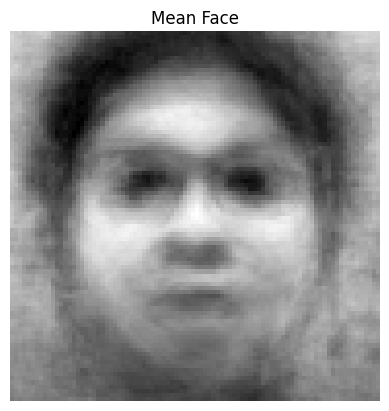

In [7]:
import matplotlib.pyplot as plt

mean_face = np.mean(X_train, axis=0)
print("Mean face shape:", mean_face.shape)

# visualize mean face of train set

mean_img = mean_face.reshape(90, 90)

plt.imshow(mean_img, cmap="gray")
plt.title("Mean Face")
plt.axis("off")
plt.show()

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

In [8]:
#we compute X.T @ X instead of X @ X.T to avoid huge computations since we have thousands of features (8100)
XtX = X_train_centered @ X_train_centered.T
XtX.shape

(65, 65)

In [9]:
eigenvalues, eigenvectors = np.linalg.eigh(XtX)

# sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors_small = eigenvectors[:, idx]

In [10]:
# converting eigenvetors of X.T @ X to eigenvectors of X @ X.T
eigenvectors_large = X_train_centered.T @ eigenvectors_small

# divide by sqrt eigenvalues
eigenvectors_large = eigenvectors_large / np.sqrt(eigenvalues + 1e-10)

# normalize
eigenvectors_large = eigenvectors_large / np.linalg.norm(eigenvectors_large, axis=0)

In [23]:
# implement dimensionality reduction by selecting top k eigenvectors out of 8100 features
k = 50  # number of principal components to keep

# sort eigenvalues by descending magnitude and keep the top k components
sorted_idx = np.argsort(eigenvalues)[::-1]
top_k_idx = sorted_idx[:k]

top_k_eigenvalues = eigenvalues[top_k_idx]
eigenvectors_reduced = eigenvectors_large[:, top_k_idx]

print("Top-k eigenvalues:", top_k_eigenvalues)
eigenvectors_reduced.shape


Top-k eigenvalues: [6385.0117  3509.7874  3061.3738  2620.2175  1697.6847  1543.5146
 1482.3673  1230.0043  1151.8365  1034.0187   923.1704   841.9469
  760.11365  656.16943  644.3016   571.3719   553.5127   540.8807
  503.69766  471.63174  447.07397  422.98462  408.52908  397.97433
  380.27875  349.9335   343.0083   329.24515  305.85007  294.36035
  276.26514  269.71594  263.6929   254.91277  247.36241  224.1505
  216.69537  209.66156  206.69614  202.74239  190.96774  181.4592
  174.85034  168.62468  166.50385  159.04102  156.33394  147.12888
  143.83119  137.8703 ]


Top-k eigenvalues: [6385.0117  3509.7874  3061.3738  2620.2175  1697.6847  1543.5146
 1482.3673  1230.0043  1151.8365  1034.0187   923.1704   841.9469
  760.11365  656.16943  644.3016   571.3719   553.5127   540.8807
  503.69766  471.63174  447.07397  422.98462  408.52908  397.97433
  380.27875  349.9335   343.0083   329.24515  305.85007  294.36035
  276.26514  269.71594  263.6929   254.91277  247.36241  224.1505
  216.69537  209.66156  206.69614  202.74239  190.96774  181.4592
  174.85034  168.62468  166.50385  159.04102  156.33394  147.12888
  143.83119  137.8703 ]


(8100, 50)

In [24]:
eigenvalues.shape

(65,)

In [25]:
# Reduce dimensionality of train sets
X_train_reduced = X_train_centered @ eigenvectors_reduced
X_train_reduced.shape



(65, 50)

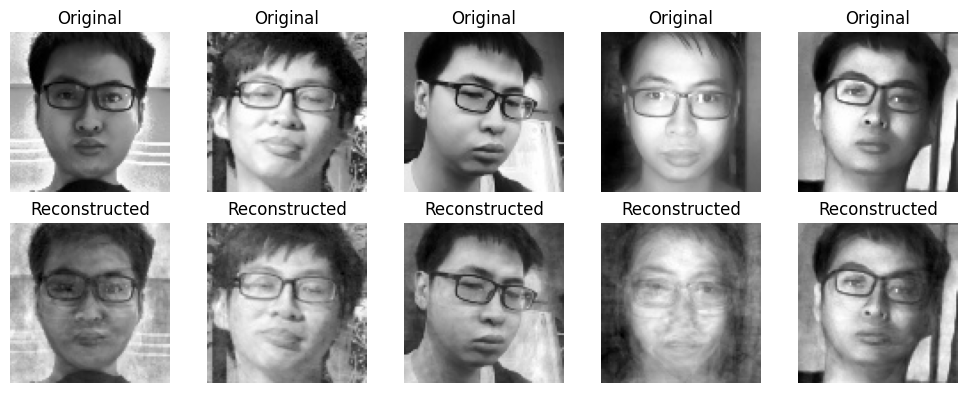

In [26]:
# reconstruct images from reduced representation
X_train_reconstructed = X_train_reduced @ eigenvectors_reduced.T + mean_face
X_train_reconstructed.shape
# visualize original vs reconstructed
n = 5  # number of images to show
plt.figure(figsize=(10, 4))
for i in range(21, 21 + n):
    # original
    plt.subplot(2, n, i - 20)
    plt.imshow(X_train[i].reshape(90, 90), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # reconstructed
    plt.subplot(2, n, n + i - 20)
    plt.imshow(X_train_reconstructed[i].reshape(90, 90), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [27]:
# LDA 
'''
n: number of features (8100 before PCA, 57 after PCA)
classes: number of classes (7)
number of samples per class (10 in train, 2 in test)
'''
N, d = X_train_reduced.shape
classes = np.unique(y_train)

overall_mean = np.mean(X_train_reduced, axis=0)

Sw = np.zeros((d, d))
Sb = np.zeros((d, d))

for c in classes:
    X_c = X_train_reduced[y_train == c]
    mean_c = np.mean(X_c, axis=0)
    
    # within-class scatter
    Sw += (X_c - mean_c).T @ (X_c - mean_c)
    
    # between-class scatter
    n_c = X_c.shape[0]
    mean_diff = (mean_c - overall_mean).reshape(-1, 1)
    Sb += n_c * (mean_diff @ mean_diff.T)

# regularization to avoid singularity
Sw += 1e-6 * np.eye(d)

# solve generalized eigenvalue problem
M = np.linalg.solve(Sw, Sb) # solving X from SwX = SbX -> X = Sw^-1 Sb X 
eigvals, eigvecs = np.linalg.eig(M)

eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# lda transformation matrix
W_lda = eigvecs[:, : len(classes) - 1]
eigvals = eigvals[: len(classes) - 1]

# normalize LDA components
norms = np.linalg.norm(W_lda, axis=0, keepdims=True)
norms[norms < 1e-12] = 1.0
W_lda = W_lda / norms



In [28]:
X_train_lda = X_train_reduced @ W_lda
X_test_lda = X_test_centered @ eigenvectors_reduced @ W_lda

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = [1, 3, 5, 7]
accuracies = {}

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_lda, y_train)
    y_pred = knn.predict(X_test_lda)
    acc = accuracy_score(y_test, y_pred)
    accuracies[k] = acc
    print(f"{k}-NN accuracy: {acc:.4f}")

best_k = max(accuracies, key=accuracies.get)
print(f"Best accuracy: {best_k}-NN = {accuracies[best_k]:.4f}")
accuracy = accuracies[1]

1-NN accuracy: 0.4783
3-NN accuracy: 0.4348
5-NN accuracy: 0.4348
7-NN accuracy: 0.4348
Best accuracy: 1-NN = 0.4783


In [30]:
accuracy

np.float64(0.4782608695652174)

In [31]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# encode string labels for SVM training
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# train SVM on LDA-transformed features
svm_clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=42)
svm_clf.fit(X_train_lda, y_train_enc)

# evaluate
y_pred_enc = svm_clf.predict(X_test_lda)
accuracy = accuracy_score(y_test_enc, y_pred_enc)
print("SVM accuracy:", accuracy)
print("Classification report:\n", classification_report(y_test_enc, y_pred_enc, target_names=label_encoder.classes_))

y_pred = label_encoder.inverse_transform(y_pred_enc)

SVM accuracy: 0.43478260869565216
Classification report:
               precision    recall  f1-score   support

   P_Fathiah       0.00      0.00      0.00         2
     P_Fazil       0.67      1.00      0.80         2
    P_Jasper       0.67      0.33      0.44         6
       P_Joe       0.33      0.50      0.40         4
    P_Mikail       0.25      0.50      0.33         2
       P_Roy       0.50      0.50      0.50         2
    P_Syarah       0.40      0.40      0.40         5

    accuracy                           0.43        23
   macro avg       0.40      0.46      0.41        23
weighted avg       0.44      0.43      0.41        23



/workspaces/IE4228-Assignment/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/IE4228-Assignment/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/IE4228-Assignment/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri